# July 29-31, Dry-run Hackathon: Qiskit Tutorial
By **Ahmed Saad El Fiky**
***

### Content:
1. Initializing Qiskit environment
2. Brief Introduction to Quantum Computing
   - Superposition
   - Entanglement
   - Single-qubit gates
   - Two-qubit gates
   - Implementation with Qiskit
   - Ex. Creating Bell state.
3. Quantum Machine Learning (QML)
   - Quantum Neural Network (QNN)
   - Motivation for Using QNNs
   - Basic components of QNN:
     - Data encoding (Feature Map)
     - Parametized Quantum Circuit (PQC) `Ansatz`
     - Measurement and Output (Post-processing and Optimization)
   - Ex. Simple QNN model

## Initializing working environment on the local machine:

Download python 3.9+ form https://www.python.org/
* Install python-3.xx.x.exe

If you require _environment management_ as opposed to just installation, go to https://www.anaconda.com/download/success/ and install Miniconda or even Anaconda as you prefer.
_Anaconda is larger and comes with a vast array of pre-installed packages, while Miniconda is smaller and only includes Conda and Python._

* Create a folder to save your work in D:
* Open Command Prompt (CMD) / Anaconda Prompt.
* Install Jupyter Notebook: __pip install notebook__
* Wait until it finishes.
* Go to: __D:__
* Open Jupyter notebook: __jupyter notebook__
* Go to the directory where you want to save your notebooks.
* Create a new _Python 3_ Notebook from the New menu on the top right.
* Install the required packages as follows.

In [ ]:
# Install the required packages
!pip install qiskit qiskit-machine-learning qiskit-aer qiskit[visualization] 

In [2]:
# Verify your qiskit & qiskit machine learning version
import qiskit, qiskit_machine_learning
print(f"Qiskit verison: {qiskit.__version__}")
print(f"Qiskit ML verison: {qiskit_machine_learning.__version__}")

Qiskit verison: 1.4.3
Qiskit ML verison: 0.8.3


In [190]:
# Ignore warnings if needed
import warnings
warnings.filterwarnings('ignore')


Now we are ready. 🥳🎉 
***

# 1. Brief Introduction:
### 1.1 Quantum computing vs. Classical computing:

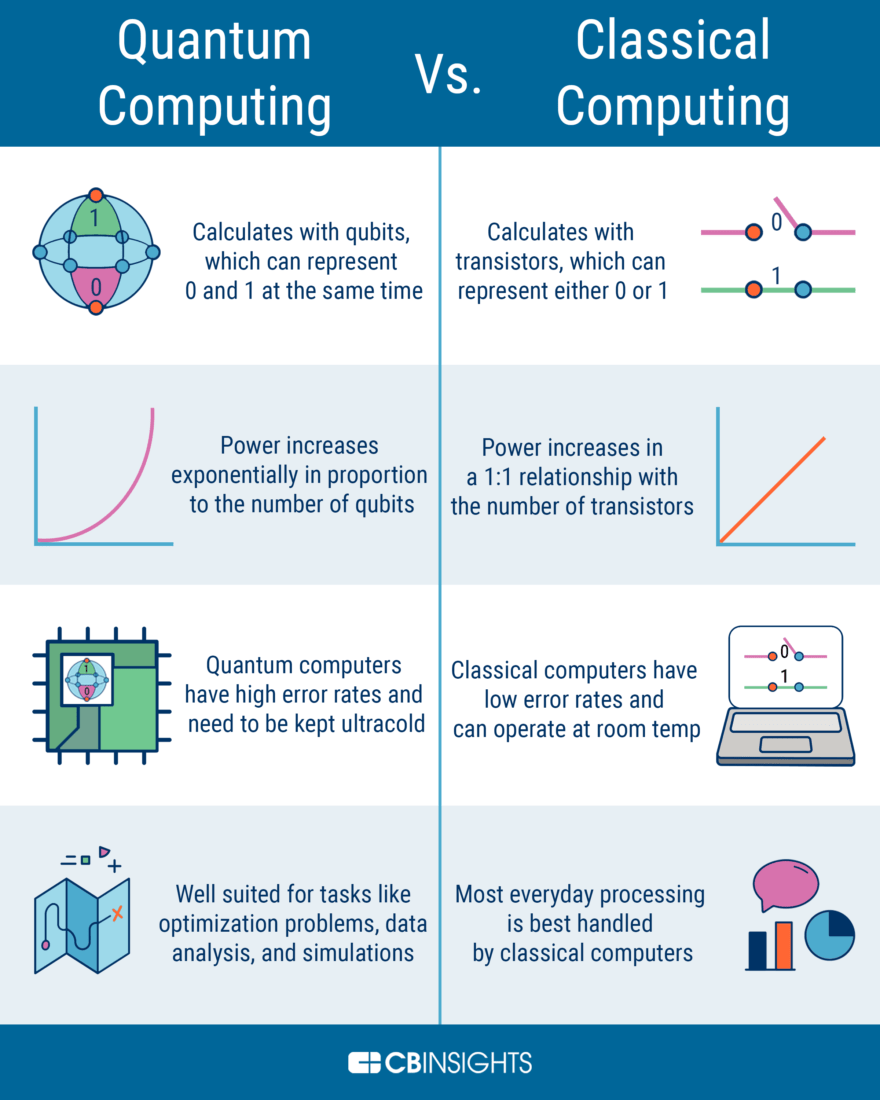

**Quantum computing** is *a type of computation that utilizes quantum mechanics to solve complex problems that are intractable for classical computers*.

It leverages the principles of superposition and entanglement to perform calculations, potentially offering significant speedups for specific tasks. 

**Key Concepts:**
* **Quantum Mechanics:**
    The laws of physics that govern the behavior of matter and energy at the atomic and subatomic levels. 

* **Qubits:**
    Unlike classical bits (which can be either 0 or 1), quantum bits (qubits) can exist in a superposition of both states (0 and 1) simultaneously. This allows quantum computers to explore multiple possibilities concurrently.
* **Superposition:**
  A quantum mechanical phenomenon where a qubit can exist in multiple states at once, analogous to a coin spinning in the air and being both heads and tails until it lands. 



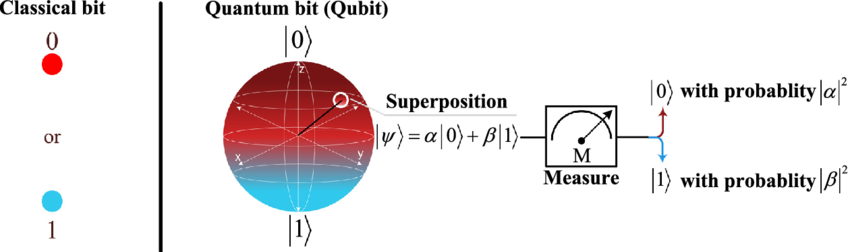

* **Entanglement**:
A phenomenon where two or more qubits become linked, such that their fates are intertwined, even when separated by large distances. 

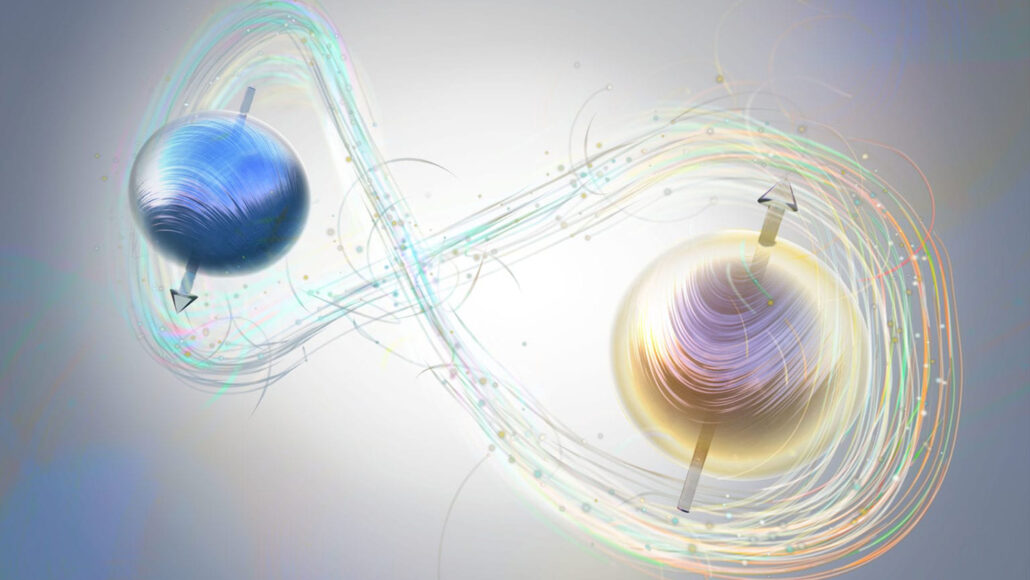

**How it works:**\
Quantum computers leverage superposition and entanglement to perform calculations in a fundamentally different way than classical computers. They don't try every possible answer simultaneously, but rather use quantum algorithms to manipulate probabilities, enhancing the likelihood of measuring the correct solution. 

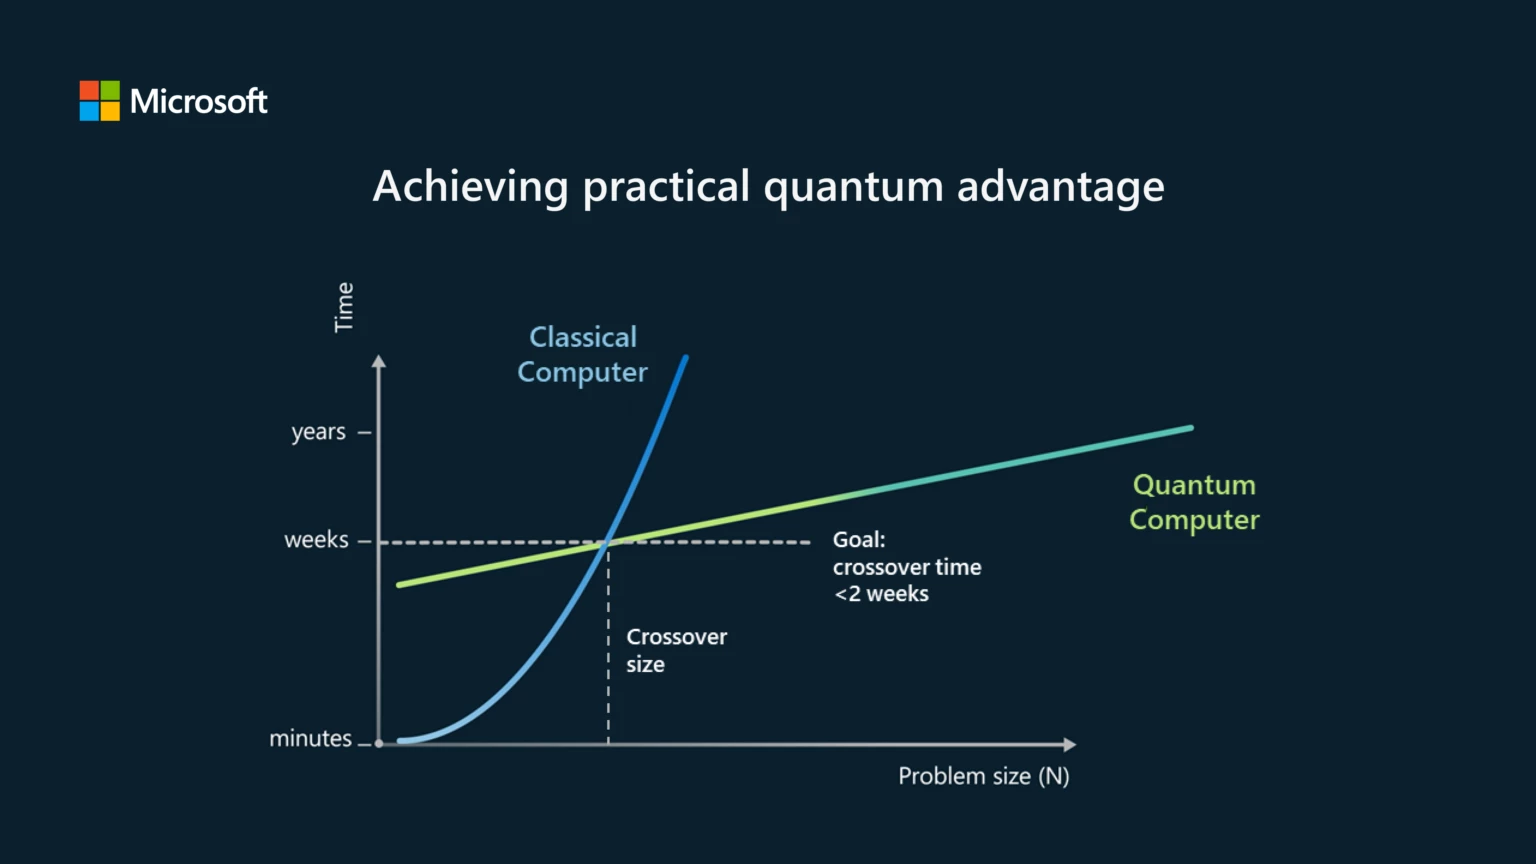

**Potential applications:** \
  Quantum computing has the potential to revolutionize various fields, including:

* **Drug discovery and materials science**: Simulating molecular interactions to design new drugs and materials. 
* **Cryptography**: Breaking current encryption methods and developing new, quantum-resistant encryption algorithms. 
* **Financial modeling**: Optimizing investment strategies and risk management. 
* **Artificial intelligence**: Accelerating machine learning algorithms and developing more powerful AI models. 
* **Logistics and optimization**: Solving complex logistical problems, such as route planning and supply chain optimization. 

***

### 1.2. Representation of a Qubit on the Bloch sphere using polar coordinates:

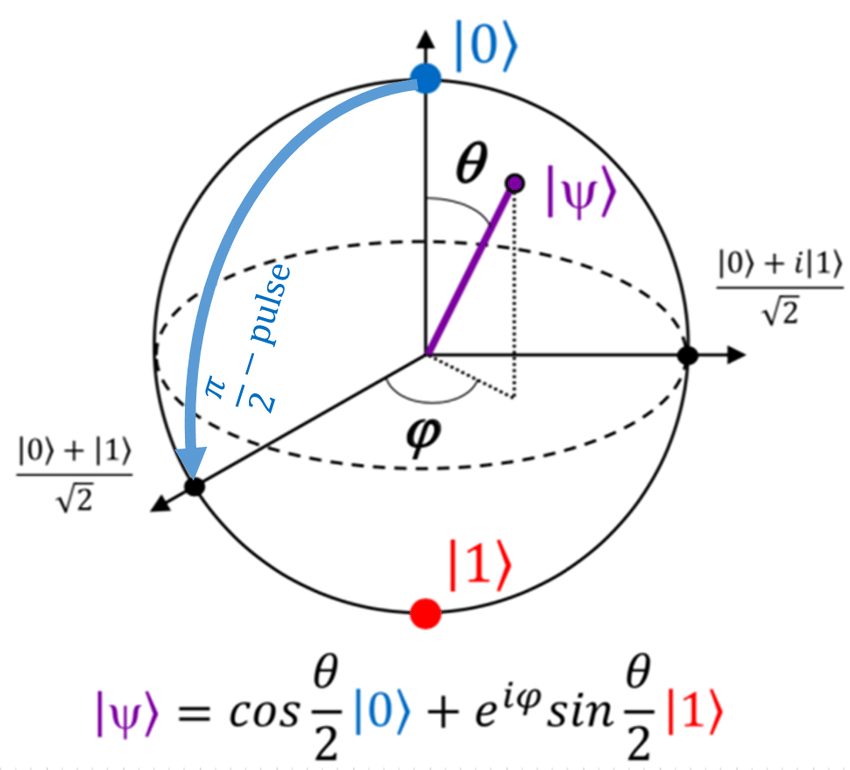

***

### 1.3. Single-Qubit Quantum Gates and Their Matrix Representations

- **Identity Gate (I):**

  $$
  I = \begin{bmatrix}
  1 & 0 \\
  0 & 1
  \end{bmatrix}
  $$

- **Pauli-X Gate (NOT Gate):**

  $$
  X = \begin{bmatrix}
  0 & 1 \\
  1 & 0
  \end{bmatrix}
  $$

- **Pauli-Y Gate:**

  $$
  Y = \begin{bmatrix}
  0 & -i \\
  i & 0
  \end{bmatrix}
  $$

- **Pauli-Z Gate:**

  $$
  Z = \begin{bmatrix}
  1 & 0 \\
  0 & -1
  \end{bmatrix}
  $$

- **Hadamard Gate (H):**

  $$
  H = \frac{1}{\sqrt{2}} \begin{bmatrix}
  1 & 1 \\
  1 & -1
  \end{bmatrix}
  $$

- **Phase Gate (S):**

  $$
  S = \begin{bmatrix}
  1 & 0 \\
  0 & i
  \end{bmatrix}
  $$

- **T Gate (π/8 Gate):**

  $$
  T = \begin{bmatrix}
  1 & 0 \\
  0 & e^{i\pi/4}
  \end{bmatrix}
  $$

- **Rotation around X-axis (Rx):**

  $$
  R_x(\theta) = \cos\left(\frac{\theta}{2}\right) I - i \sin\left(\frac{\theta}{2}\right) X = 
  \begin{bmatrix}
  \cos\left(\frac{\theta}{2}\right) & -i \sin\left(\frac{\theta}{2}\right) \\
  -i \sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right)
  \end{bmatrix}
  $$

- **Rotation around Y-axis (Ry):**

  $$
  R_y(\theta) = \cos\left(\frac{\theta}{2}\right) I - i \sin\left(\frac{\theta}{2}\right) Y = 
  \begin{bmatrix}
  \cos\left(\frac{\theta}{2}\right) & -\sin\left(\frac{\theta}{2}\right) \\
  \sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right)
  \end{bmatrix}
  $$

- **Rotation around Z-axis (Rz):**

  $$
  R_z(\theta) = \begin{bmatrix}
  e^{-i\theta/2} & 0 \\
  0 & e^{i\theta/2}
  \end{bmatrix}
  $$

- **Any arbitrary single-qubit unitary operator can be demonstrated by 3 rotations about only 2 axes**:
$$ U = e^{i\theta} R_z(\alpha) R_y(\beta) R_z(\gamma) $$

  The global phase factor $\exp(iθ)$ can be ignored.

***

### 1.4. Two-Qubit Quantum Gates and Their Matrix Representations

- **CNOT Gate (Controlled-X):**

  $$
  \text{CNOT} = \begin{bmatrix}
  1 & 0 & 0 & 0 \\
  0 & 1 & 0 & 0 \\
  0 & 0 & 0 & 1 \\
  0 & 0 & 1 & 0
  \end{bmatrix}
  $$

- **CZ Gate (Controlled-Z):**

  $$
  \text{CZ} = \begin{bmatrix}
  1 & 0 & 0 & 0 \\
  0 & 1 & 0 & 0 \\
  0 & 0 & 1 & 0 \\
  0 & 0 & 0 & -1
  \end{bmatrix}
  $$

- **SWAP Gate:**

  $$
  \text{SWAP} = \begin{bmatrix}
  1 & 0 & 0 & 0 \\
  0 & 0 & 1 & 0 \\
  0 & 1 & 0 & 0 \\
  0 & 0 & 0 & 1
  \end{bmatrix}
  $$

- **Controlled-Hadamard (CH) Gate:**

  $$
  \text{CH} = \begin{bmatrix}
  1 & 0 & 0 & 0 \\
  0 & 1 & 0 & 0 \\
  0 & 0 & \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\
  0 & 0 & \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
  \end{bmatrix}
  $$

- **Controlled-Phase (CP) Gate:**

  $$
  \text{CP}(\phi) = \begin{bmatrix}
  1 & 0 & 0 & 0 \\
  0 & 1 & 0 & 0 \\
  0 & 0 & 1 & 0 \\
  0 & 0 & 0 & e^{i\phi}
  \end{bmatrix}
  $$

***

# 2. Build your first quantum circuit
<h3> One qubit circuit</h3>

* Design a quantum circuit with a single quantum bit and a single classical bit.

* Apply the NOT operator on the quantum bit.

* Then measure the quantum bit, the outcome of which will be saved on the classical bit.

In [34]:
# Import required objects
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Operator, Statevector
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_bloch_multivector, plot_bloch_vector
# import matplotlib.pyplot as plt

<IPython.core.display.Latex object>

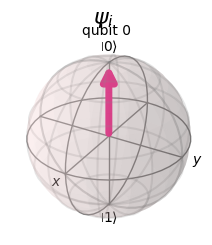

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

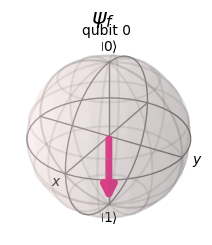

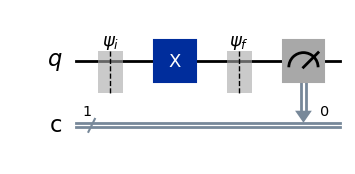

In [135]:
# Define quantum and classical registers, and then a quantum circuit
q = QuantumRegister(1, 'q') # initially in state |0>
c = ClassicalRegister(1, 'c')
qc = QuantumCircuit(q, c)

# display the initial state vector
qc.barrier(label='$\psi_i$')
# display(Statevector(qc).draw('latex', prefix='\psi_i = '))
display(Statevector.from_instruction(qc).draw('latex', prefix='\psi_i = '))

# Visualize the state vector on the Bloch sphere
display(plot_bloch_multivector(Statevector(qc), title="$\psi_i$", figsize=(2.5,2.5)))

# apply NOT operator x-gate
qc.x(q[0])

# display the operator of the quantum circuit
# display(Operator(qc).draw('latex', prefix='X = '))
display(Operator.from_circuit(qc).draw('latex', prefix='X = '))

# display the initial state vector
qc.barrier(label='$\psi_f$')
display(Statevector(qc).draw('latex', prefix='\psi_f = '))

# Visualize the state vector on the Bloch sphere
display(plot_bloch_multivector(Statevector(qc), title="$\psi_f$", figsize=(2.5,2.5)))

# measure the quantum bit, and store the outcome on the classical bit
qc.measure(q, c)

# visualize the quantum circuit
display(qc.draw(output='mpl'))

<h3>Execute the circuit</h3>

A quantum program can be executed on a real quantum computer or a local classical simulator or a simulator in the cloud. Here we use a local classical simulator provided by Qiskit and so our results will be (almost) accurate.

{'1': 1000}


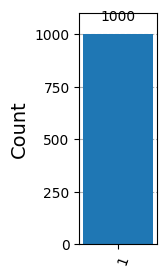

In [32]:
# execute the circuit on a local simulator
job = AerSimulator().run(qc, shots=1000) # default shots = 1024

# get the result of the outcome
counts = job.result().get_counts(qc)
print(counts) # counts is a dictionary

# show the result using histogram
plot_histogram(counts, figsize=(1,3))

***
### A quantum circuit with more quantum bits:

<IPython.core.display.Latex object>

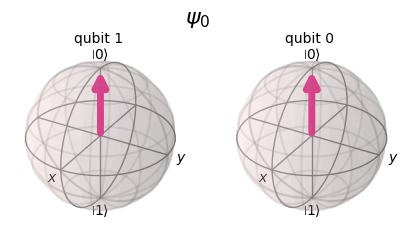

<IPython.core.display.Latex object>

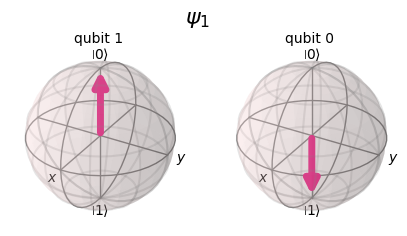

<IPython.core.display.Latex object>

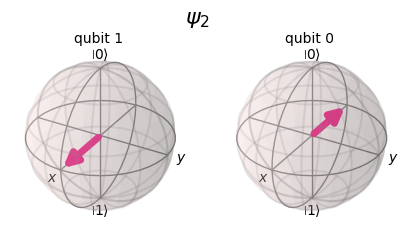

Operator of the whole quantum circuit:


<IPython.core.display.Latex object>

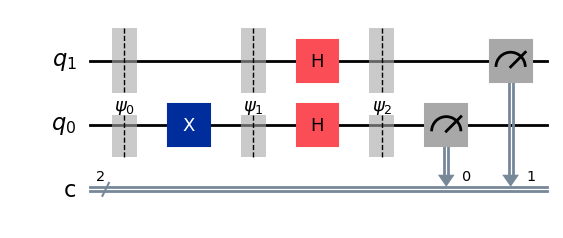

In [60]:
# A quantum circuit with three quantum and classical bits 

# define quantum and classical registers and then quantum circuit
q2 = QuantumRegister(2, 'q')
c2 = ClassicalRegister(2, 'c')
qc2 = QuantumCircuit(q2, c2)

# Alternative
# qc = QuantumCircuit(2, 2)  # initialize a 2-qubit and 2-bit circuit

# define a barrier (for a better visualization)
qc2.barrier(label="$\psi_0$") # assign the label

# display the initial statec
display(Statevector(qc2).draw('latex', prefix='\psi_0 = '))

# Visualize the state vector on the Bloch sphere
display(plot_bloch_multivector(Statevector(qc2), title="$\psi_0$", figsize=(2.5,2.5), reverse_bits=True))

# apply NOT operator on the first qubit
qc2.x(q2[0])

# barrier with assigned label
qc2.barrier(label="$\psi_1$")

# display the current state
display(Statevector(qc2).draw('latex', prefix='\psi_1 = '))
# display(Statevector.from_instruction(qc2).draw('latex'))

# Visualize the state vector on the Bloch sphere
display(plot_bloch_multivector(Statevector(qc2), title="$\psi_1$", figsize=(2.5,2.5), reverse_bits=True))

# apply Hadamard gates on all qubits
qc2.h(q2)
# qc2.h(q2[0])
# qc2.h(q2[1])

# barrier with assigned label
qc2.barrier(label="$\psi_2$")

# display the final state
display(Statevector(qc2).draw('latex', prefix='\psi_2 = '))

# Visualize the state vector on the Bloch sphere
display(plot_bloch_multivector(Statevector(qc2), title="$\psi_2$", figsize=(2.5,2.5), reverse_bits=True))

# display the operator of the quantum circuit
print("Operator of the whole quantum circuit:")
display(Operator(qc2).draw('latex', prefix='U = '))

# if the sizes of quantum and classical registers are the same, we can define measurements with a single line of code
qc2.measure(q2, c2)

# draw the circuit in reverse order of bits (to be consistent with the ket notation)
display(qc2.draw(output='mpl', reverse_bits=True, plot_barriers= True))

{'01': 247, '10': 242, '11': 257, '00': 254}


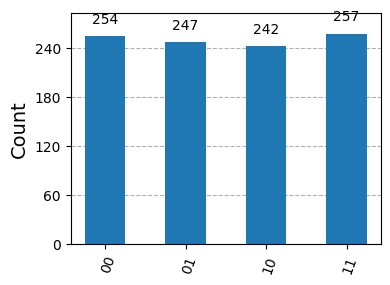

In [45]:
# execute the circuit on a local simulator
job = AerSimulator().run(qc2, shots=1000) # default shots = 1024

# get the result of the outcome
counts = job.result().get_counts(qc2)
print(counts) # counts is a dictionary

# show the result using histogram
plot_histogram(counts, figsize=(4,3))

***
### Applying single-qubit gates:

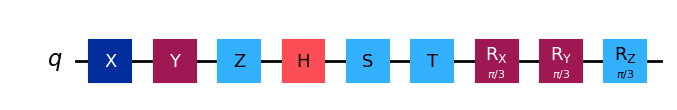

In [56]:
# Applying single-qubit gates:

from qiskit import QuantumCircuit
from numpy import pi

qc = QuantumCircuit(1)  # initialize a 1-qubit circuit

# Pauli-X gate
qc.x(0)

# Pauli-Y gate
qc.y(0)

# Pauli-Z gate
qc.z(0)

# Hadamard gate
qc.h(0)

# Phase gate (S)
qc.s(0)

# T gate (π/8 gate)
qc.t(0)

# Rx rotation with angle theta
theta = pi / 3
qc.rx(theta, 0)

# Ry rotation with angle theta
qc.ry(theta, 0)

# Rz rotation with angle theta
qc.rz(theta, 0)

# Display the quantum circuit
qc.draw('mpl')

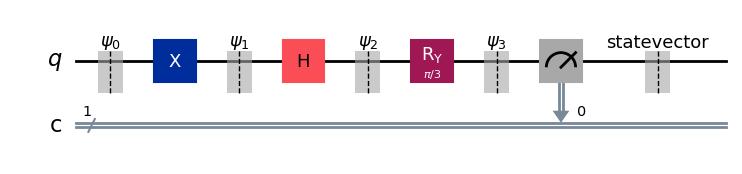

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

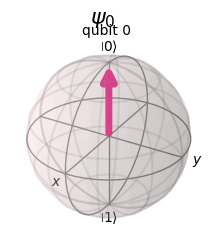

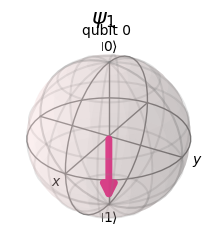

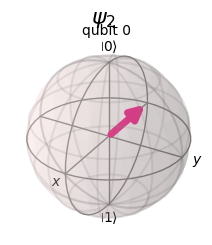

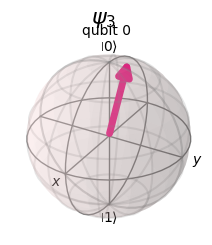

In [133]:
# Example:

from qiskit import QuantumCircuit
from numpy import pi

# Define quantum and classical registers and then quantum circuit
q = QuantumRegister(1, 'q') # initially in state |0>
c = ClassicalRegister(1, 'c')
qc = QuantumCircuit(q, c)

# Add barrier with label
qc.barrier(label="$\psi_0$")
psi0 = Statevector(qc)

# apply NOT operator x-gate
qc.x(q[0])

# Add barrier with label
qc.barrier(label="$\psi_1$")
psi1 = Statevector(qc)

# apply Hadamard gate
qc.h(q[0])

# Add barrier with label
qc.barrier(label="$\psi_2$")
psi2 = Statevector(qc)

# Apply rotation around z-axis on the previous circuit
qc.ry(pi/3, q[0])

# Add barrier with label
qc.barrier(label="$\psi_3$")
psi3 = Statevector(qc)

# measure the quantum system
qc.measure(q, c)

# Request to save the statevector
qc.save_statevector()

# Display the quantum circuit
display(qc.draw(output='mpl', plot_barriers= True))

display(Statevector(psi0).draw('latex', prefix='\psi_0 = '))
display(Statevector(psi1).draw('latex', prefix='\psi_1 = '))
display(Statevector(psi2).draw('latex', prefix='\psi_2 = '))
display(Statevector(psi3).draw('latex', prefix='\psi_3 = '))

# Visualize the statevectors on the Bloch sphere
display(plot_bloch_multivector(psi0, title="$\psi_0$", figsize=(2.5,2.5)))
display(plot_bloch_multivector(psi1, title="$\psi_1$", figsize=(2.5,2.5)))
display(plot_bloch_multivector(psi2, title="$\psi_2$", figsize=(2.5,2.5)))
display(plot_bloch_multivector(psi3, title="$\psi_3$", figsize=(2.5,2.5)))

In [134]:
# Initialize the simulator with the statevector method
sv_sim = AerSimulator(method='statevector')

# execute the circuit on a local simulator
job = sv_sim.run(qc)

# get the result of the outcome
counts = job.result().get_counts(qc)
print(counts) # counts is a dictionary

# get the state vector
psif = job.result().get_statevector()
display(psif.draw('latex', prefix='ψ_f = '))

{'0': 950, '1': 74}


<IPython.core.display.Latex object>

### Applying Two-qubit gates:

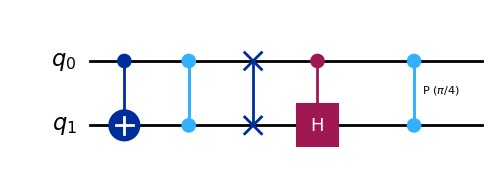

In [61]:
# Applying Two-qubit gates:

from qiskit import QuantumCircuit
from numpy import pi

qc = QuantumCircuit(2)  # initialize a 2-qubit circuit

# CNOT gate: control=q0, target=q1
qc.cx(0, 1)

# CZ gate: control=q0, target=q1
qc.cz(0, 1)

# SWAP gate: swap q0 and q1
qc.swap(0, 1)

# Controlled-Hadamard: apply H on q1 if q0=1
qc.ch(0, 1)

# Controlled-Phase gate with angle phi
phi = pi / 4
qc.cp(phi, 0, 1)

# Display the quantum circuit
qc.draw('mpl')

***

### 3. Entanglement and Bell states:

- **Entanglement quantum circuit**:

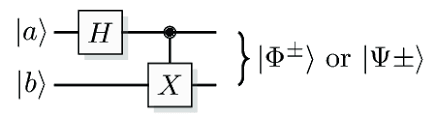

| **Input State $\ket{ab}$**  | **Output State(Bell State)**  |
|-----------------|----------------------------------------|
|$\ket{00}$ | $ \ket{\phi^+} = \frac{1}{\sqrt{2}}(\ket{00} + \ket{11})$ |
|$\ket{01}$ | $ \ket{\psi^+} = \frac{1}{\sqrt{2}}(\ket{01} + \ket{10})$ |
|$\ket{10}$ | $ \ket{\phi^-} = \frac{1}{\sqrt{2}}(\ket{00} - \ket{11})$ |
|$\ket{11}$ | $ \ket{\psi^-} = \frac{1}{\sqrt{2}}(\ket{01} - \ket{10})$ |

The output qubits are correlated to each other >> **Entangled state**.

For the state $ \ket{\phi^+} = \frac{1}{\sqrt{2}}(\ket{00} + \ket{11})$:\
We can observe either state $ \ket{00} $ or state $ \ket{11} $, if meaused the 2 qubits.

If Alice observes her qubit secretly:
<ul>
    <li> When Alice sees the result $ \ket{0} $, then Bob's qubit also collapses to state $ \ket{0} $. Bob cannot observe state $ \ket{1} $. </li>
    <li> When Alice sees the result $ \ket{1} $, then Bobs's qubit also collapses to state $ \ket{1} $. Bob cannot observe state $ \ket{0} $. </li>
</ul>

Experimental results have confirmed that this happens even if there is a physical distance between Alice's and Bob's qubits. 

It seems correlated quantum particles can "affect each other" instantly, even if they are in different parts of the universe. **"Spooky Action at a distance."**

The quantum state of two entangled qubits cannot be written as $ \ket{u} \otimes \ket{v} $. **" Cannot be factorized."**
***

<h3> Challenge 1 </h3>

* Design the EPR pair entanglement circuit, which gives the output Bell state: 
$$|\phi^+\rangle = \frac{1}{\sqrt{2}} (|00\rangle + |11\rangle)$$

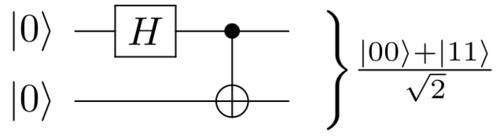

* Execute the circuit on a local simulator and show the result using histogram.
***

<IPython.core.display.Latex object>

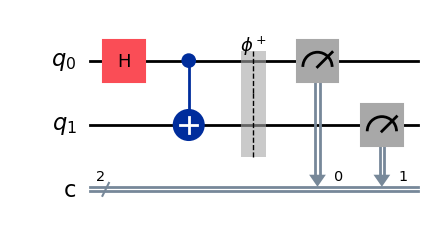

In [155]:
# Import required objects
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Operator, Statevector
from qiskit.visualization import plot_histogram

# define quantum and classical registers and then quantum circuit
q = QuantumRegister(2, 'q')
c = ClassicalRegister(2, 'c')
qc = QuantumCircuit(q,c)

# apply the Hadamard operator on the first qubit (q[0])
qc.h(0)
# apply the CNOT operator on the two qubits with the first qubit q[0] as a control and q[1] as a target
qc.cx(0,1)
# barrier with assigned label
qc.barrier(label='$ϕ^+$')
# display the final state
display(Statevector(qc).draw('latex', prefix='ϕ^+ = '))

# measure the quantum bit, and store the outcome on the classical bit
qc.measure(q,c)
# visualize the quantum circuit
qc.draw('mpl')

{'11': 495, '00': 505}


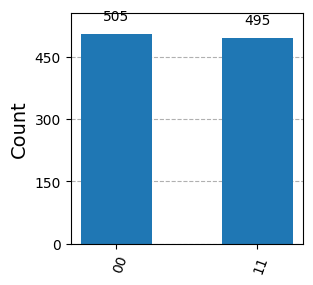

In [149]:
# execute the circuit on a local simulator (1000 times)
job = AerSimulator().run(qc, shots=1000)

# get the result of the outcome
counts = job.result().get_counts()
print(counts) # counts is a dictionary

# show the result using histogram
plot_histogram(counts, figsize=(3,3))

***

# Quantum machine learning (QML):
is a rapidly evolving field that combines quantum computing with machine learning techniques.

**Quantum Neural Networks (QNNs)**: machine learning models that leverage quantum-mechanical phenomena to process and learn from data.

#### Motivation for Using QNNs

- **Processing Quantum Data**: When data itself is naturally quantum (e.g., outputs of quantum experiments or other quantum processes), it is often more efficient to keep it in a quantum representation. QNNs can learn directly from quantum states without costly classical readout.
- **High-Dimensional Feature Spaces**: Quantum states live in exponentially large Hilbert spaces. A suitably chosen encoding scheme might allow QNNs to express complex functions that are difficult for classical networks to replicate.
- **Potential for Speedups**: While not guaranteed for every problem, certain tasks may see quantum speedup or more efficient training and evaluation, especially if the hardware can exploit parallelism in quantum states.
- **Avoiding Overfitting**: Some works have observed that certain variational circuits can resist overfitting more naturally than classical models of a similar size, though this is still an active area of research.

## QNN vs CNN:
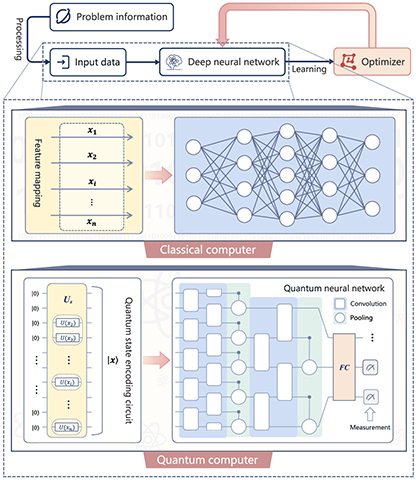

### Basic components of QNN
A typical quantum neural network for supervised or unsupervised tasks can be broken down into three major components:

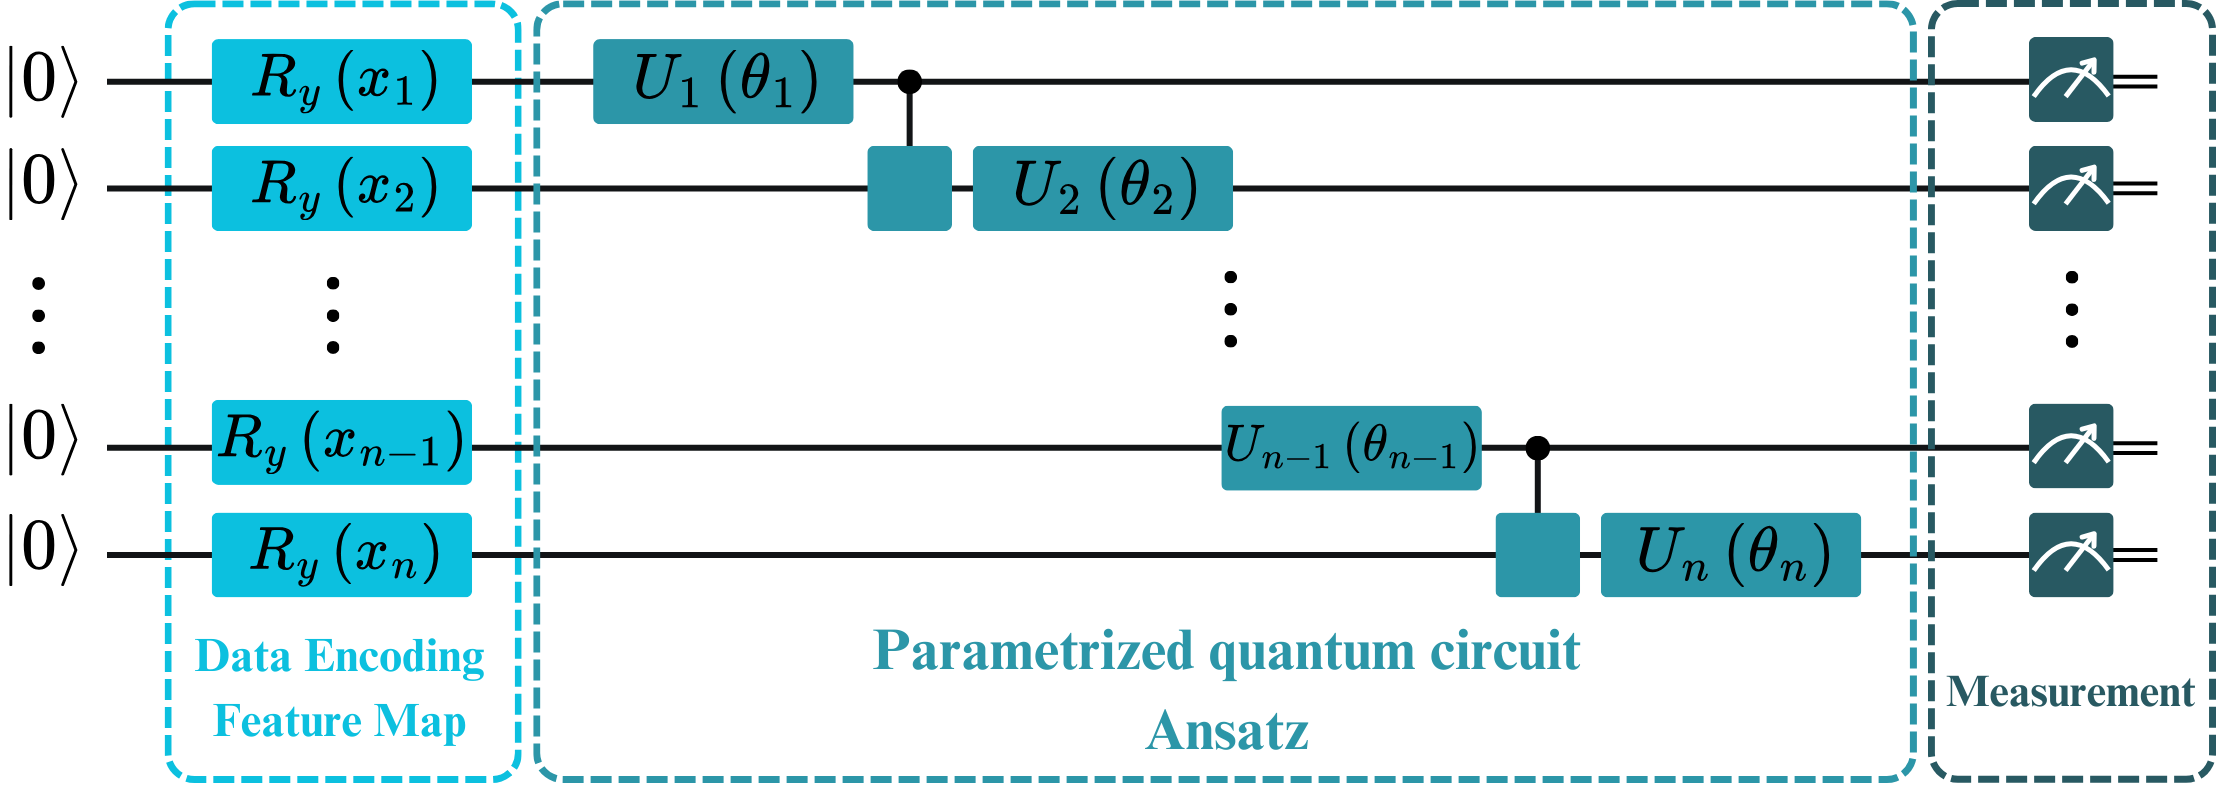


![quantum model.png](<attachment:quantum model.png>)
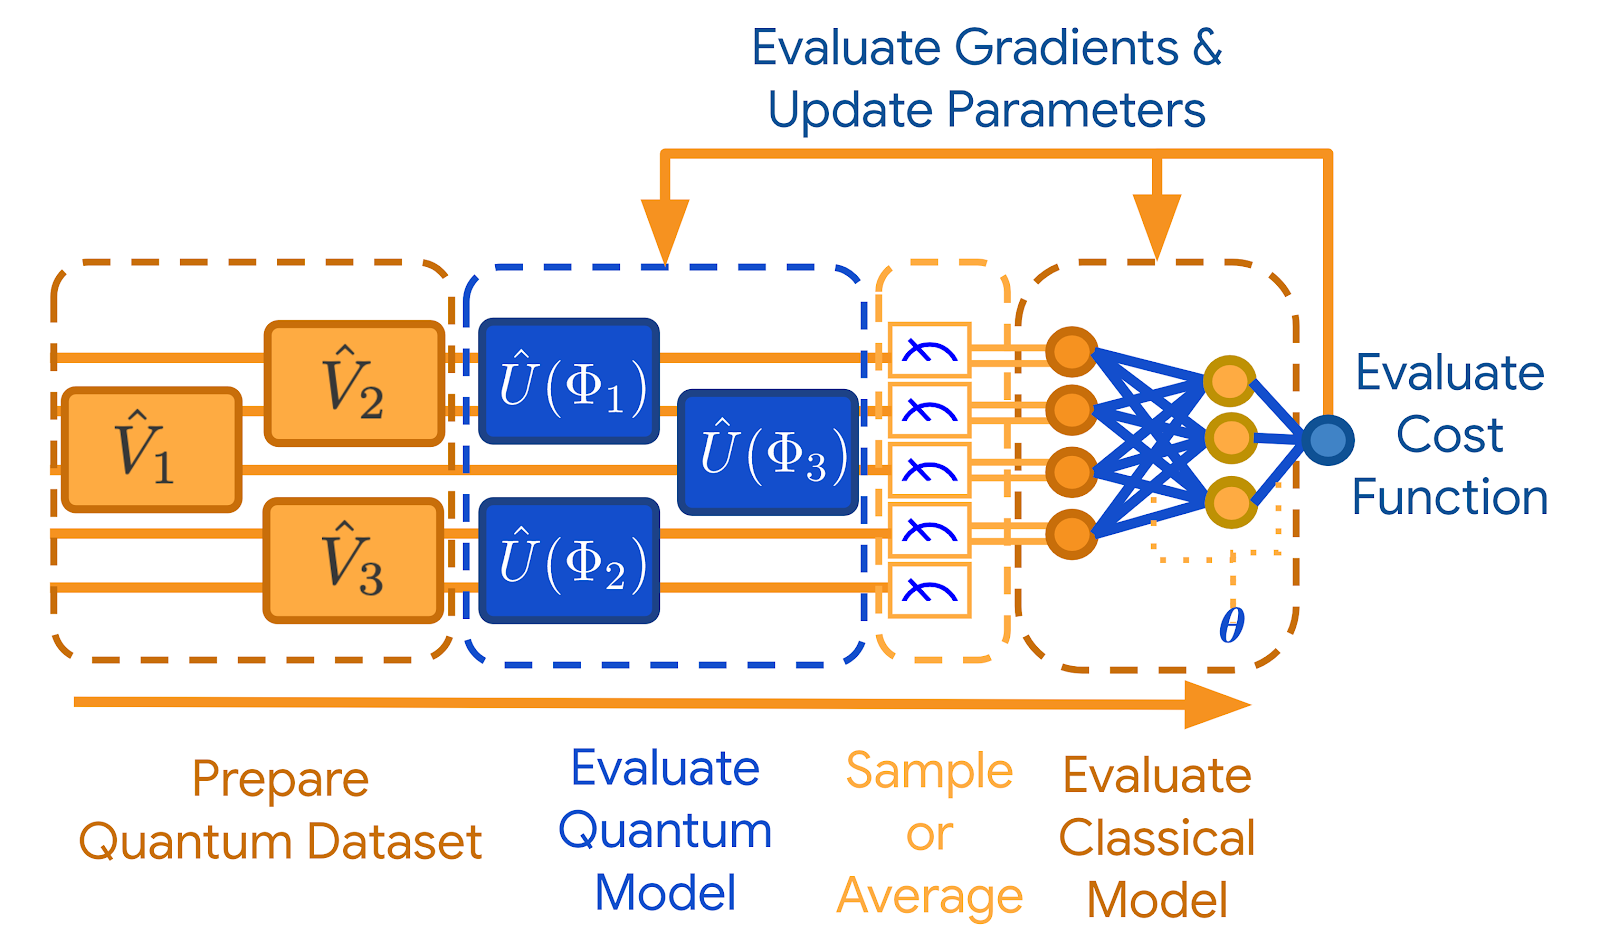

1. **Quantum Data Encoding**   
Before a quantum circuit can process **classical data**, the data $x ∈ ℝ^d$ must be **mapped to a quantum state  $|ψ(x)⟩$**. \
This feature map step is essential: different encoding methods can drastically alter a QNN’s performance. Common approaches are:


| **Encoding**     | **Description**                                    | **Qubits**         | **Circuit Depth**   | **Pros**                                | **Cons**                                 |
|------------------|----------------------------------------------------|--------------------|---------------------|-----------------------------------------|------------------------------------------|
| **Basis**        | Load bits of *x* directly into computational basis | One per bit        | Minimal             | Trivial circuits; exact bit fidelity    | Qubit‑heavy; no superposition benefits   |
| **Amplitude**    | Map $x ∈ ℝ^n$ to amplitudes of $log₂(N)$ qubits     | $log₂(N)$          | High (state prep)   | Exponential compression                 | Very deep; noise‑sensitive               |
| **Angle**        | Encode each feature $xᵢ$ as a rotation angle $Ry(xᵢ)$ | One per feature    | Low–medium          | Simple; shallow                         | Linear qubit scaling; needs entanglers   |
| **Hamiltonian**  | Evolve under data‑dependent $U(x) = exp(−iH(x)t)$ | Varies with H      | Medium–high         | Captures global correlations            | Requires problem‑specific design         |
| **QRAM**         | Use quantum RAM to load data in superposition      | log₂(*N*) + ancilla| Medium–high         | Fast queries; amplitude‑style loading   | QRAM hardware unproven; complex setup    |

---

### Key Trade‑Offs

- **Resources vs. Depth:**  
  Amplitude/QRAM → fewer qubits but deeper circuits  
  Basis → more qubits but very shallow circuits

- **Noise Resistance:**  
  Angle, Basis > Hamiltonian > Amplitude, QRAM

- **Expressivity:**  
  Hamiltonian > Amplitude >> Angle > Basis

---

### When to Use

- **Small vectors (≤10 features):** → Angle  
- **High-dimensional data:** → Amplitude or QRAM  
- **Boolean/discrete data:** → Basis  
- **Physics-inspired models:** → Hamiltonian  


### Example: Basis Encoding
Imagine having a classical dataset with features that can take on discrete values. For example, the distance versus time dataset of a car's journey traveling between two cities. 

Example dataset:

| Distance (km) | Time (hours) |
|---------------|--------------|
| 2           | 1            |
| 5           | 2            |
| 7           | 3            |
| 8           | 4            |
| 10           | 5           |

This dataset contains two features: distance and time. Each feature can take on values from a finite set, such as integers from 1 to 5 in this case.§

Each feature in this dataset can be represented as a quantum state, where the values of the features correspond to the basis states of qubits.

In basis encoding, each feature is represented by a quantum bit (qubit) in its computational basis state. For example, if you have a feature that can take on values 0 or 1, you can represent it as a qubit in the |0⟩ or |1⟩ state.
However, if the feature can take on more than two values, you can use multiple qubits to represent it. 

To encode, we need to map the classical data to quantum states. Basis encoding means that we represent each value in the spin or the bit information of the qubit. 

First, we need to convert them to binary. Based on the needed digits of the binary representation, we can determine how many qubits we need. For example, if we have values between distance 0 and 10, we need at least 4 qubits to represent the values in binary (0000 to 1010).

Hence, for the distance feature, we can represent the values as follows:
- 0 km: |0000⟩
- 1 km: |0001⟩
- 2 km: |0010⟩
- 3 km: |0011⟩
- 4 km: |0100⟩
- 5 km: |0101⟩
- 6 km: |0110⟩
- 7 km: |0111⟩
- 8 km: |1000⟩
- 9 km: |1001⟩
- 10 km: |1010⟩

As an exercise, you can try to encode the time feature in a similar way in the following cell. You can use the folllowing code snippet to help you with the encoding:

In [141]:
def binary_representation(value, num_bits):
    """Convert a value to its binary representation with a fixed number of bits."""
    ### Your code here ToDo 
    
    return 
    ###

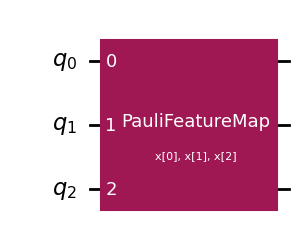

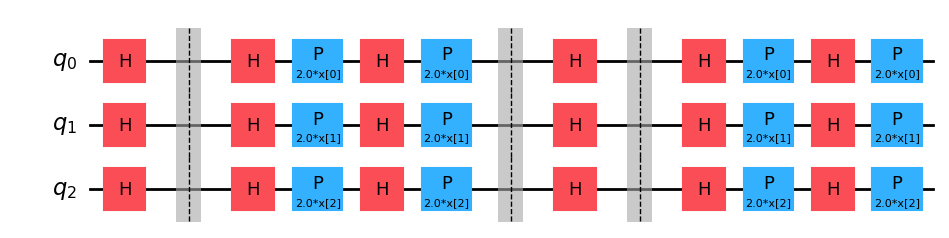

In [158]:
from qiskit.circuit.library import PauliFeatureMap, ZFeatureMap, ZZFeatureMap, RealAmplitudes, TwoLocal, EfficientSU2

feature_dim = 3
feature_map = PauliFeatureMap(feature_dimension=feature_dim, paulis=['X', 'Z'], reps=2, insert_barriers=True)
display(feature_map.draw('mpl'))
display(feature_map.decompose().draw('mpl'))

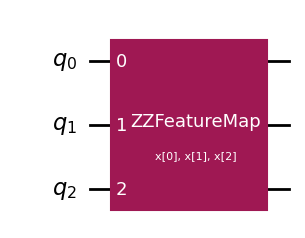

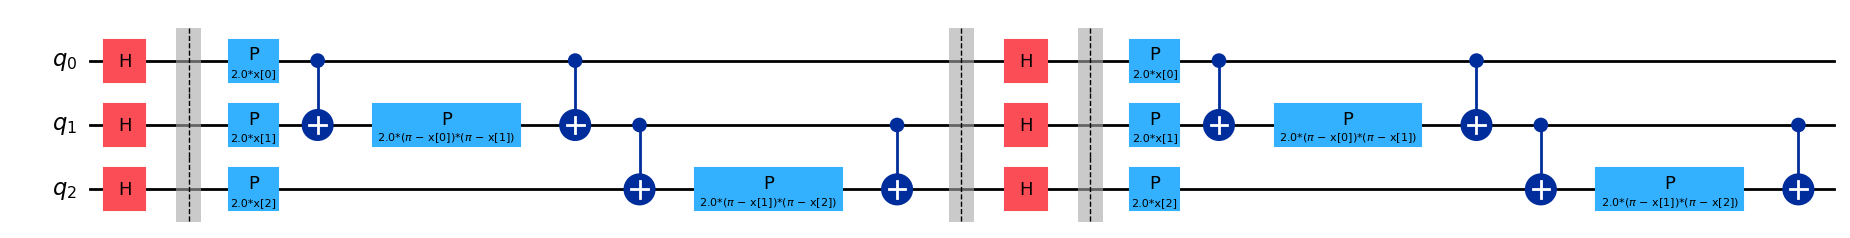

In [165]:
from qiskit.circuit.library import PauliFeatureMap, ZFeatureMap, ZZFeatureMap, RealAmplitudes, TwoLocal, EfficientSU2

feature_dim = 3
feature_map = ZZFeatureMap(feature_dimension=feature_dim, entanglement='linear', insert_barriers=True)
display(feature_map.draw('mpl'))
display(feature_map.decompose().draw('mpl', fold=-1))

***
2. **Variational Circuit (Processing)**

After encoding, the network applies a **variational form (or ansatz) with learnable parameters  $θ$** . This circuit is designed to "transform" the encoded state in a way reminiscent of how layers in a classical neural network transform the activations. The QNN's variational form may be structured in layers, each consisting of:

- **Parametric Single-Qubit Rotations**: For example,  `Ry(θ)`  or  `Rz(ϕ)` .
- **Entangling Gates**: Such as `controlled-NOT (CNOT)`, `controlled-Z`, or other `two-qubit operations`, arranged in a pattern (`linear`, `cyclic`, `all-to-all`) to introduce entanglement between qubits.


In essence, feature maps and variational forms are both **variational circuits**, but they differ in purpose. Feature maps depend on the input data, while the variational form depends on the optimizable parameters **$θ$** .

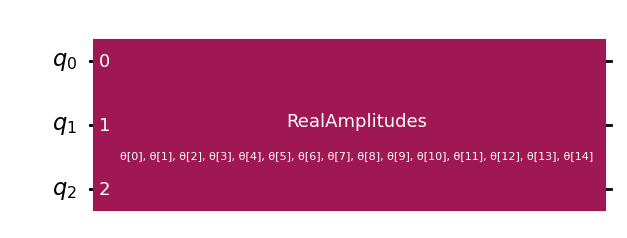

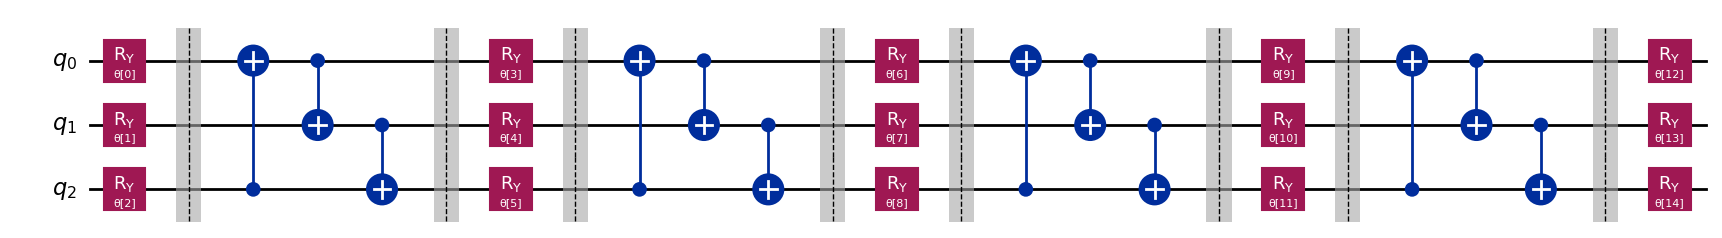

In [160]:
ansatz = RealAmplitudes(num_qubits=feature_dim, entanglement='circular', reps=4, insert_barriers=True)
display(ansatz.draw('mpl'))
display(ansatz.decompose().draw('mpl', fold=-1))

***
3. **Measurement and Output**
Finally, measurements map the quantum state back to a classical output. Depending on the QNN's goal—e.g., binary classification, multi-class classification, or regression—one might measure:

- The **expectation value** of a certain operator (e.g., measuring one qubit or the parity of multiple qubits).
- A **probability distribution** over multiple measurement outcomes (e.g., for sampling or generative models).

Choosing the measurement operator carefully is crucial, as it directly determines how the model's output is read and used in a loss function `optimizer`.

***

### Simple Quantum Neural Network

Let's imagine we have the following dataset obtained sin and cos wave functions: $ z = sin(x) + cos(y) + noise $ where $ x, y $ are the input features and $ z $ is the output label. We can encode the input feature into a quantum state and then apply a quantum circuit to process it.

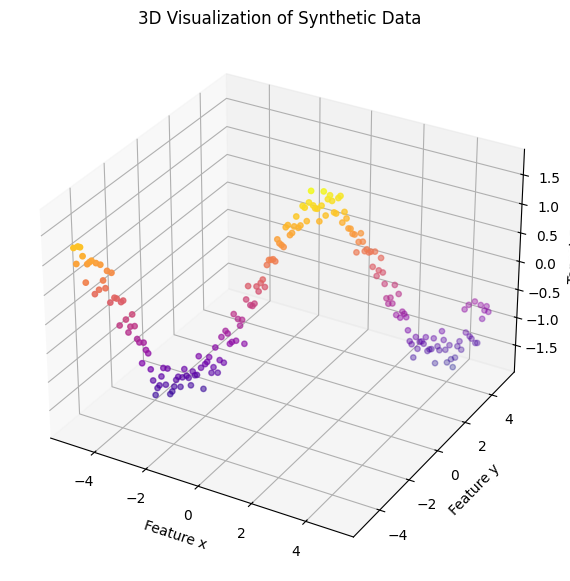

In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def generate_data(n_points=200, noise_level=0.2):
    """
    Generates a DataFrame with synthetic features x, y and target z.
    
    Returns:
        pd.DataFrame: DataFrame with columns ['x', 'y', 'z']
    """
    x = np.linspace(-5, 5, n_points)
    y = np.linspace(-5, 5, n_points)
    z = np.sin(x) + np.cos(y) + noise_level * np.random.randn(n_points)
    
    return pd.DataFrame({'x': x, 'y': y, 'z': z})

def visualize_3d_data(df):
    """
    Visualizes the DataFrame (with columns x, y, z) in a 3D scatter plot.
    """
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(df['x'], df['y'], df['z'], c=df['z'], cmap='plasma', s=15)
    ax.set_xlabel("Feature x")
    ax.set_ylabel("Feature y")
    ax.set_zlabel("Target z")
    ax.set_title("3D Visualization of Synthetic Data")
    plt.show()

# Example usage
df_data = generate_data()
visualize_3d_data(df_data)


In [192]:
df_data.describe()

,x,y,z
count,2.000000e+02,2.000000e+02,200.000000
mean,1.421085e-16,1.421085e-16,-0.177930
std,2.908502e+00,2.908502e+00,0.993175
min,-5.000000e+00,-5.000000e+00,-1.738195
25%,-2.500000e+00,-2.500000e+00,-1.144981
50%,4.440892e-16,4.440892e-16,-0.333696
75%,2.500000e+00,2.500000e+00,0.746702
max,5.000000e+00,5.000000e+00,1.682694


In [193]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

In [194]:
# Initialize an array to store evaluations of the objective function during optimization
objective_func_vals = []

# Define the callback function
def callback_graph(weights: np.ndarray, loss: float) -> None:
    """
    Callback for NeuralNetworkRegressor that records and prints
    the loss at each optimizer iteration.

    Parameters
    ----------
    weights : np.ndarray
        The current parameters of the QNN (unused here).
    loss : float
        The current objective function (loss) value.
    """
    objective_func_vals.append(loss)
    print(f"Iteration {len(objective_func_vals):3d} — Loss: {loss:.6f}")

In [195]:
# Initialize an array to store evaluations of the objective function during optimization
objective_func_vals = []

# Define the callback function
def callback_graph(*args):
    """
    Universal callback for NeuralNetworkRegressor / SPSA / ADAM, etc.
    It will be called with one of these argument‐patterns:
      - (weights, loss)
      - (nfev, weights, loss)
      - (loss,)
      - (nfev, weights, loss, grad)
    This will extract the loss (the last numeric argument),
    append it to `objective_func_vals`, and print it.
    """
    # find the first float in args (assuming loss is a float)
    loss = None
    for a in args:
        if isinstance(a, float):
            loss = a
    if loss is None:
        # fallback: assume the last arg is loss
        loss = args[-1]
    
    # Store loss
    objective_func_vals.append(loss)   
    iteration = len(objective_func_vals)

    # Print every 10 iterations
    if iteration % 10 == 0:
        print(f"Iteration {iteration:3d} — Loss: {loss:.6f}")

#### Let's start with training **1-D** or 1-qubit quantum neural networks:
    Often, we need to encode the input feature into a quantum state. But first we need to scale the input feature to a range that is suitable for quantum circuits. This is typically done by normalizing the data to a range between 0 and 1 or -1 and 1.

In [196]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Extract input features and target from DataFrame
# X = df_data[['x', 'y']]     # Features: x and y
X1 = df_data[['x']]     # Features: x and y
y = df_data['z']             # Target: z

# Split data into training and testing sets (80/20)
X_train1, X_test1, y_train, y_test = train_test_split(
    X1, y, test_size=0.2, random_state=42
)

# Scale input features to range [-1, 1]
xscaler = MinMaxScaler(feature_range=(-1, 1))
X_train1_scaled = xscaler.fit_transform(X_train1)
X_test1_scaled = xscaler.transform(X_test1)

# Scale target values to range [-1, 1]
yscaler = MinMaxScaler(feature_range=(-1, 1))

# Reshape target arrays to 2D for the scaler
y_train1_scaled = yscaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = yscaler.transform(y_test.values.reshape(-1, 1))

### Quantum Neural Network different encoding methods and ansatzes:
Try to play a bit with the parameters of the quantum neural network, to get a feeling of how they affect the performance of the quantum neural network. For example, changing the number of repetitions in the `ZZFeatureMap` or the number of `reps` in the `TwoLocal` ansatz. You can also try different rotation blocks or entanglement blocks in the `TwoLocal` ansatz. You can also try different iterations to test the convergence of loss.

Check the impact on the quality of the predictions. To test any prediction, you need to re-evaluate the same data and compare. 

Note that, if you have one qubit, the entanglement blocks will not have any effect, entanglement only works with more than one qubit, obviously. 

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Iteration  10 — Loss: 0.335456
Iteration  20 — Loss: 0.200882
Iteration  30 — Loss: 0.188111
Iteration  40 — Loss: 0.186741
Iteration  50 — Loss: 0.188412
Training time: 28.2 s


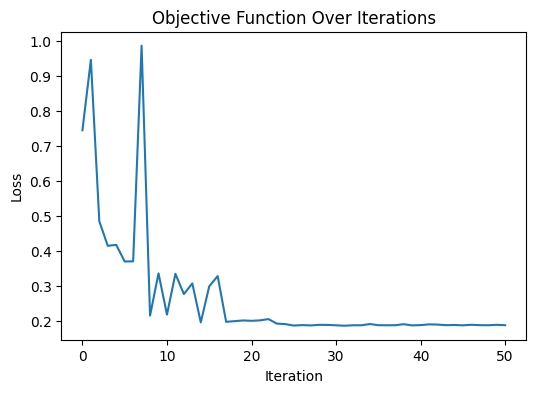

In [200]:
import time
import matplotlib.pyplot as plt

# Qiskit circuits & new V2 primitives
from qiskit.circuit.library import PauliFeatureMap, EfficientSU2
from qiskit.primitives import StatevectorEstimator, StatevectorSampler

# Qiskit‑Machine‑Learning
from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN
from qiskit_machine_learning.algorithms import NeuralNetworkRegressor
from qiskit_machine_learning.optimizers import L_BFGS_B, COBYLA, ADAM, SPSA
from qiskit_machine_learning.circuit.library import QNNCircuit

# --------------- Setup --------------------------------

# 1) Use the new V2 Estimator for expectation‑value QNNs
estimator = StatevectorEstimator()

# 2) (Optional) If you ever want a sampling‑based QNN, use StatevectorSampler + SamplerQNN
# sampler = StatevectorSampler()
# qnn = SamplerQNN(circuit=qc, sampler=sampler, input_gradients=True)

# Feature dimension
feature_dim = X_train1_scaled.shape[1]

# --- 1. Build the QNN circuit ---

feature_map = PauliFeatureMap(feature_dimension=feature_dim, reps=1, paulis=['Y','Z'])
ansatz      = EfficientSU2(num_qubits=feature_dim, reps=1)
qc = QNNCircuit(feature_map=feature_map, ansatz=ansatz)

# --- 2. Wrap into an EstimatorQNN using the V2 primitive ---

qnn = EstimatorQNN(
    circuit=qc,
    estimator=estimator,
    input_gradients=True           # enable analytic gradients
)

# --- 3. Build the sklearn‑style regressor ---

regressor = NeuralNetworkRegressor(
    neural_network=qnn,
    loss="squared_error",         # mean squared error
    optimizer=COBYLA(maxiter=100),
    callback=callback_graph       # populates your objective_func_vals list
)

objective_func_vals = []

# --- 4. Train ---

start = time.time()
regressor.fit(X_train1_scaled, y_train_scaled)
elapsed = time.time() - start
print(f"Training time: {elapsed:.1f} s")

plt.rcParams["figure.figsize"] = (6, 4)
plt.plot(objective_func_vals)
plt.title("Objective Function Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

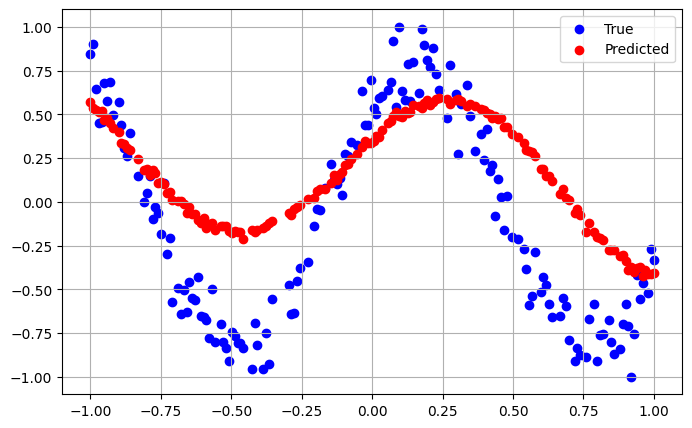

R² Train score: 0.4401
R² Test score: 0.2865


In [201]:
# --- 5. Predict & Evaluate ---

y_pred = regressor.predict(X_train1_scaled)
plt.figure(figsize=(8,5))
plt.scatter(X_train1_scaled, y_train_scaled, color='blue',  label='True')
plt.scatter(X_train1_scaled, y_pred, color='red',   label='Predicted')
plt.legend(); plt.grid(True); plt.show()

print(f"R² Train score: {regressor.score(X_train1_scaled, y_train_scaled):.4f}")
print(f"R² Test score: {regressor.score(X_test1_scaled, y_test_scaled):.4f}")

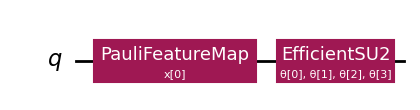

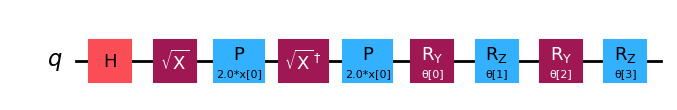

In [202]:
display(qc.draw('mpl'))
display(qc.decompose().draw('mpl', fold=-1))

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Iteration  10 — Loss: 0.209715
Iteration  20 — Loss: 0.180877
Iteration  30 — Loss: 0.182672
Iteration  40 — Loss: 0.179793
Iteration  50 — Loss: 0.181708
Iteration  60 — Loss: 0.182537
Training time: 43.6 s


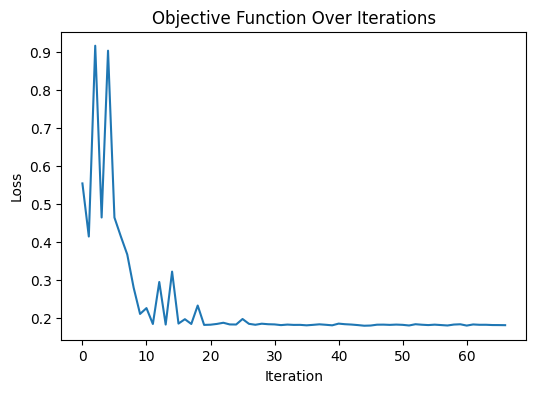

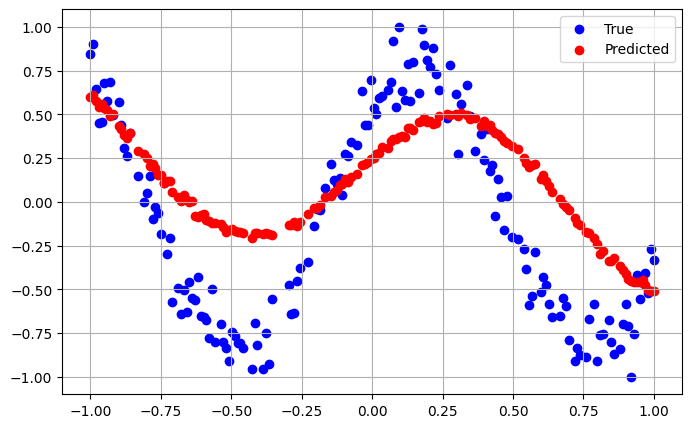

R² Train score: 0.4592
R² Test score: 0.3585


In [203]:
import time
import matplotlib.pyplot as plt

# Qiskit circuits & new V2 primitives
from qiskit.circuit.library import PauliFeatureMap, EfficientSU2
from qiskit.primitives import StatevectorEstimator, StatevectorSampler

# Qiskit‑Machine‑Learning
from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN
from qiskit_machine_learning.algorithms import NeuralNetworkRegressor
from qiskit_machine_learning.optimizers import L_BFGS_B, COBYLA, ADAM, SPSA
from qiskit_machine_learning.circuit.library import QNNCircuit

# --------------- Setup --------------------------------

# 1) Use the new V2 Estimator for expectation‑value QNNs
estimator = StatevectorEstimator()

# 2) (Optional) If you ever want a sampling‑based QNN, use StatevectorSampler + SamplerQNN
# sampler = StatevectorSampler()
# qnn = SamplerQNN(circuit=qc, sampler=sampler, input_gradients=True)

# Feature dimension
feature_dim = X_train1_scaled.shape[1]

# --- 1. Build the QNN circuit ---

feature_map = PauliFeatureMap(feature_dimension=feature_dim, reps=1, paulis=['Z', 'Y'])
ansatz      = EfficientSU2(num_qubits=feature_dim, reps=2)
qc = QNNCircuit(feature_map=feature_map, ansatz=ansatz)

# --- 2. Wrap into an EstimatorQNN using the V2 primitive ---

qnn = EstimatorQNN(
    circuit=qc,
    estimator=estimator,
    input_gradients=True           # enable analytic gradients
)

# --- 3. Build the sklearn‑style regressor ---

regressor = NeuralNetworkRegressor(
    neural_network=qnn,
    loss="squared_error",         # mean squared error
    optimizer=COBYLA(maxiter=100),
    callback=callback_graph       # populates your objective_func_vals list
)

objective_func_vals = []

# --- 4. Train ---

start = time.time()
regressor.fit(X_train1_scaled, y_train_scaled)
elapsed = time.time() - start
print(f"Training time: {elapsed:.1f} s")

plt.rcParams["figure.figsize"] = (6, 4)
plt.plot(objective_func_vals)
plt.title("Objective Function Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

# --- 5. Predict & Evaluate ---

y_pred = regressor.predict(X_train1_scaled)
plt.figure(figsize=(8,5))
plt.scatter(X_train1_scaled, y_train_scaled, color='blue',  label='True')
plt.scatter(X_train1_scaled, y_pred, color='red',   label='Predicted')
plt.legend(); plt.grid(True); plt.show()

print(f"R² Train score: {regressor.score(X_train1_scaled, y_train_scaled):.4f}")
print(f"R² Test score: {regressor.score(X_test1_scaled, y_test_scaled):.4f}")

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Iteration  10 — Loss: 0.939702
Iteration  20 — Loss: 0.450367
Iteration  30 — Loss: 0.447636
Iteration  40 — Loss: 0.448519
Iteration  50 — Loss: 0.447121
Iteration  60 — Loss: 0.447728
Iteration  70 — Loss: 0.449198
Training time: 58.2 s


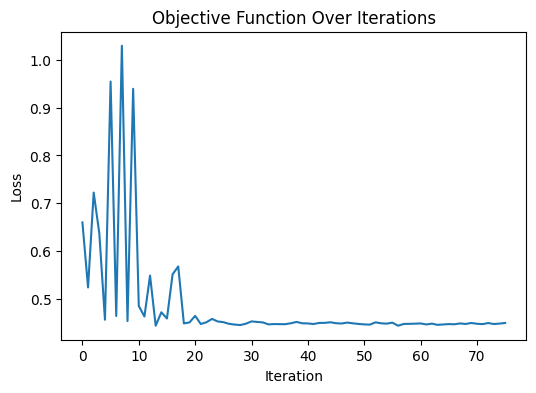

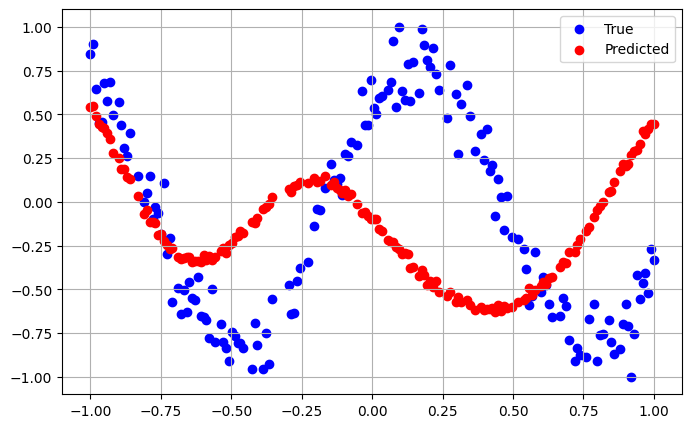

R² Train score: -0.3242
R² Test score: -0.5069


In [205]:
import time
import matplotlib.pyplot as plt

# Qiskit circuits & new V2 primitives
from qiskit.circuit.library import PauliFeatureMap, EfficientSU2
from qiskit.primitives import StatevectorEstimator, StatevectorSampler

# Qiskit‑Machine‑Learning
from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN
from qiskit_machine_learning.algorithms import NeuralNetworkRegressor
from qiskit_machine_learning.optimizers import L_BFGS_B, COBYLA, ADAM, SPSA
from qiskit_machine_learning.circuit.library import QNNCircuit

# --------------- Setup --------------------------------

# 1) Use the new V2 Estimator for expectation‑value QNNs
estimator = StatevectorEstimator()

# 2) (Optional) If you ever want a sampling‑based QNN, use StatevectorSampler + SamplerQNN
# sampler = StatevectorSampler()
# qnn = SamplerQNN(circuit=qc, sampler=sampler, input_gradients=True)

# Feature dimension
feature_dim = X_train1_scaled.shape[1]

# --- 1. Build the QNN circuit ---

feature_map = PauliFeatureMap(feature_dimension=feature_dim, reps=2, paulis=['Y','Z'])
ansatz      = EfficientSU2(num_qubits=feature_dim, reps=3)
qc = QNNCircuit(feature_map=feature_map, ansatz=ansatz)

# --- 2. Wrap into an EstimatorQNN using the V2 primitive ---

qnn = EstimatorQNN(
    circuit=qc,
    estimator=estimator,
    input_gradients=True           # enable analytic gradients
)

# --- 3. Build the sklearn‑style regressor ---

regressor = NeuralNetworkRegressor(
    neural_network=qnn,
    loss="squared_error",         # mean squared error
    optimizer=COBYLA(maxiter=100),
    callback=callback_graph       # populates your objective_func_vals list
)

objective_func_vals = []

# --- 4. Train ---

start = time.time()
regressor.fit(X_train1_scaled, y_train_scaled)
elapsed = time.time() - start
print(f"Training time: {elapsed:.1f} s")

plt.rcParams["figure.figsize"] = (6, 4)
plt.plot(objective_func_vals)
plt.title("Objective Function Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

# --- 5. Predict & Evaluate ---

y_pred = regressor.predict(X_train1_scaled)
plt.figure(figsize=(8,5))
plt.scatter(X_train1_scaled, y_train_scaled, color='blue',  label='True')
plt.scatter(X_train1_scaled, y_pred, color='red',   label='Predicted')
plt.legend(); plt.grid(True); plt.show()

print(f"R² Train score: {regressor.score(X_train1_scaled, y_train_scaled):.4f}")
print(f"R² Test score: {regressor.score(X_test1_scaled, y_test_scaled):.4f}")


Iteration  10 — Loss: 0.181285
Training took 186.3 s


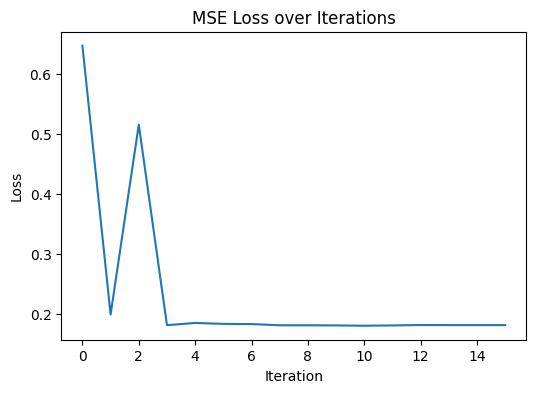

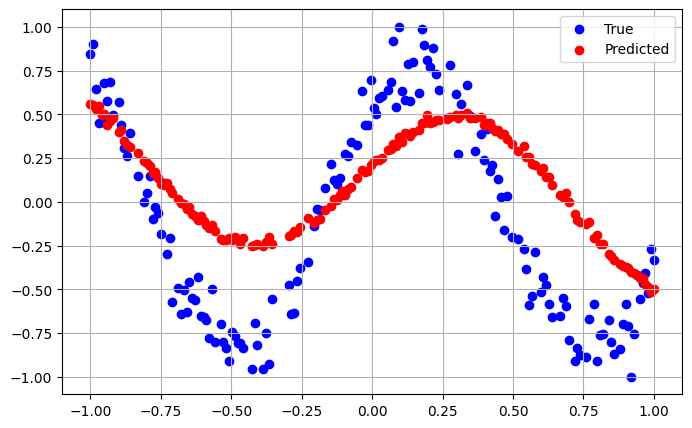

R² Train score: 0.4640
R² Test score: 0.3619


In [207]:
import time
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliFeatureMap, EfficientSU2
from qiskit.primitives import StatevectorEstimator
from qiskit.transpiler import PassManager

from qiskit_machine_learning.gradients import ParamShiftEstimatorGradient
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.algorithms import NeuralNetworkRegressor
from qiskit_machine_learning.optimizers import L_BFGS_B, COBYLA

# 0) Setup data & callback
# X_data, y_data, and callback_graph must already be defined
objective_func_vals = []

# 1) Choose the V2 Estimator primitive
estimator = StatevectorEstimator()

# 2) Build the feature‑map and the ansatz separately
feature_dim = X_train1_scaled.shape[1]
feature_map = PauliFeatureMap(feature_dimension=feature_dim, reps=1, paulis=['Y','Z'], insert_barriers=True)
ansatz      = EfficientSU2(num_qubits=feature_dim, reps=2, insert_barriers=True)

# 3) Manually stitch them together into one QuantumCircuit
qc = QuantumCircuit(feature_dim)
qc.compose(feature_map,   qubits=range(feature_dim), inplace=True)
qc.compose(ansatz,        qubits=range(feature_dim), inplace=True)

# 4) Manually extract exactly which Parameters are “data inputs” vs “trainable weights”
input_params  = list(feature_map.parameters)  # these get bound to X_data
weight_params = list(ansatz.parameters)       # these get optimized, the trainable θ’s

# 5) Build an explicit Param‑Shift gradient for analytic derivatives
# -- Create a ParamShift gradient rule tied to your Estimator primitive
gradient    = ParamShiftEstimatorGradient(estimator=estimator)

# 6) (Optional) If your backend needs it, add any custom transpilation passes
# pass_manager = PassManager()

# 7) Now create your QNN with everything spelled out
qnn = EstimatorQNN(
    circuit=qc,
    estimator=estimator,
    gradient=gradient,
    input_gradients=True,
    # pass_manager=pass_manager,
    input_params=input_params,
    weight_params=weight_params
)

# 8) Wrap it in the sklearn‑style regressor
regressor = NeuralNetworkRegressor(
    neural_network=qnn,
    loss="squared_error",
    optimizer=L_BFGS_B(maxiter=100),
    callback=callback_graph
)

# 9) Train it
start = time.time()
regressor.fit(X_train1_scaled, y_train_scaled)
print(f"Training took {time.time()-start:.1f} s")

# 10) Plot convergence
plt.plot(objective_func_vals)
plt.title("MSE Loss over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

# --- 5. Predict & Evaluate ---

y_pred = regressor.predict(X_train1_scaled)
plt.figure(figsize=(8,5))
plt.scatter(X_train1_scaled, y_train_scaled, color='blue',  label='True')
plt.scatter(X_train1_scaled, y_pred, color='red',   label='Predicted')
plt.legend(); plt.grid(True); plt.show()

print(f"R² Train score: {regressor.score(X_train1_scaled, y_train_scaled):.4f}")
print(f"R² Test score: {regressor.score(X_test1_scaled, y_test_scaled):.4f}")

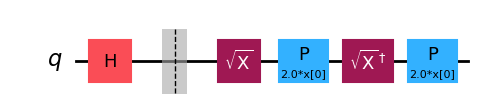

In [208]:
feature_map.decompose().draw('mpl')

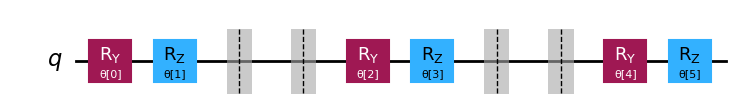

In [209]:
ansatz.decompose().draw('mpl')

#### Let's increase the dimensionality to 2-dim and use 2 qubits:

In [210]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Extract input features and target from DataFrame
X = df_data[['x', 'y']]     # Features: x and y
y = df_data['z']             # Target: z

# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale input features to range [-1, 1]
xscaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = xscaler.fit_transform(X_train)
X_test_scaled = xscaler.transform(X_test)

# Scale target values to range [-1, 1]
yscaler = MinMaxScaler(feature_range=(-1, 1))

# Reshape target arrays to 2D for the scaler
y_train_scaled = yscaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = yscaler.transform(y_test.values.reshape(-1, 1))

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Iteration  10 — Loss: 0.707459
Iteration  20 — Loss: 0.363515
Iteration  30 — Loss: 0.003626
Iteration  40 — Loss: 0.114315
Iteration  50 — Loss: 0.038874
Iteration  60 — Loss: 0.016862
Iteration  70 — Loss: 0.014097
Iteration  80 — Loss: 0.008438
Iteration  90 — Loss: 0.023238
Iteration 100 — Loss: 0.029235
Iteration 110 — Loss: 0.004114
Iteration 120 — Loss: 0.005077
Iteration 130 — Loss: 0.007661
Iteration 140 — Loss: 0.001279
Iteration 150 — Loss: 0.014894
Training time: 598.3 s


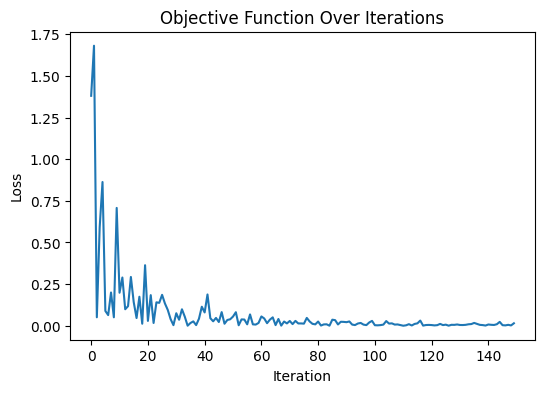

In [211]:
import time
import matplotlib.pyplot as plt

# Qiskit circuits & new V2 primitives
from qiskit.circuit.library import PauliFeatureMap, EfficientSU2, ZZFeatureMap
from qiskit.primitives import StatevectorEstimator, StatevectorSampler

# Qiskit‑Machine‑Learning
from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN
from qiskit_machine_learning.algorithms import NeuralNetworkRegressor
from qiskit_machine_learning.optimizers import L_BFGS_B, COBYLA, ADAM, SPSA
from qiskit_machine_learning.circuit.library import QNNCircuit

# --------------- Setup --------------------------------

# 1) Use the new V2 Estimator for expectation‑value QNNs
estimator = StatevectorEstimator()

# 2) (Optional) If you ever want a sampling‑based QNN, use StatevectorSampler + SamplerQNN
# sampler = StatevectorSampler()
# qnn = SamplerQNN(circuit=qc, sampler=sampler, input_gradients=True)

# Feature dimension
feature_dim = X_train_scaled.shape[1]

# --- 1. Build the QNN circuit ---

feature_map = ZZFeatureMap(feature_dimension=feature_dim, reps=1)
ansatz      = EfficientSU2(num_qubits=feature_dim, reps=2, entanglement="linear" , insert_barriers=True)
qc = QNNCircuit(feature_map=feature_map, ansatz=ansatz)

# --- 2. Wrap into an EstimatorQNN using the V2 primitive ---

qnn = EstimatorQNN(
    circuit=qc,
    estimator=estimator,
    input_gradients=True           # enable analytic gradients
)

# --- 3. Build the sklearn‑style regressor ---

regressor = NeuralNetworkRegressor(
    neural_network=qnn,
    loss="squared_error",         # mean squared error
    optimizer=SPSA(maxiter=150, callback=callback_graph),
    # callback=callback_graph,       # populates your objective_func_vals list
)

objective_func_vals = []

# --- 4. Train ---

start = time.time()
regressor.fit(X_train_scaled, y_train_scaled)
elapsed = time.time() - start
print(f"Training time: {elapsed:.1f} s")

plt.rcParams["figure.figsize"] = (6, 4)
plt.plot(objective_func_vals)
plt.title("Objective Function Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

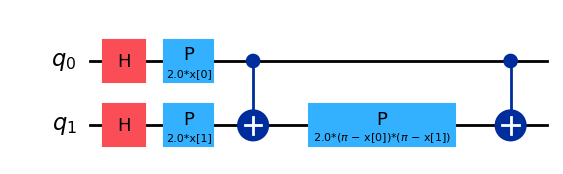

In [214]:
feature_map.decompose().draw('mpl')

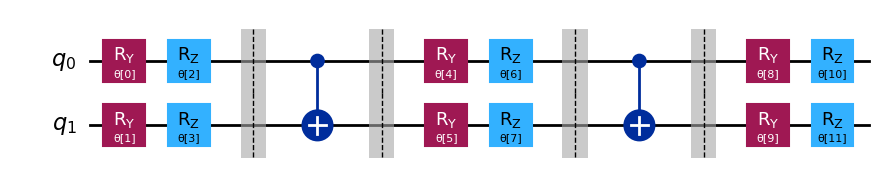

In [215]:
ansatz.decompose().draw('mpl')

In [216]:
# --- Predict on training data ---
y_pred_train = regressor.predict(X_train_scaled)
y_pred_test = regressor.predict(X_test_scaled)

In [217]:
# --- R² Scores ---
r2_train = regressor.score(X_train_scaled, y_train_scaled)
r2_test = regressor.score(X_test_scaled, y_test_scaled)
print(f"R² Train Score: {r2_train:.4f}")
print(f"R² Test Score: {r2_test:.4f}")

R² Train Score: 0.6501
R² Test Score: 0.5891


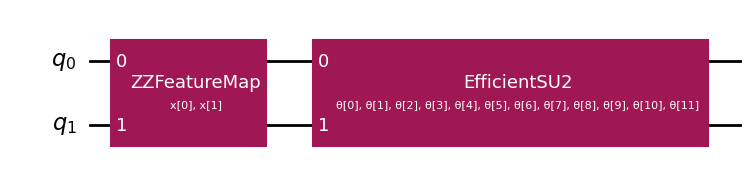

In [218]:
qc.draw('mpl')

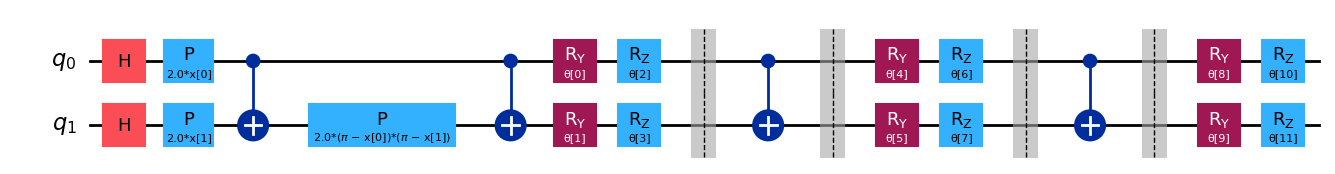

In [219]:
qc.decompose().draw('mpl')

In [222]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def evaluate_and_plot(regressor, 
                      X_train_scaled, y_train_scaled, 
                      X_test_scaled, y_test_scaled,
                      df,
                      feature_scaler,   # Scaler used for features
                      target_scaler):   # Scaler used for target
    """
    Evaluate regression model and visualize:
    - Original dataset (raw values)
    - True training targets (unscaled)
    - Predicted values (unscaled)
    All in a single 3D plot.
    """
    # --- Predictions ---
    y_pred_train = regressor.predict(X_train_scaled)
    y_pred_test = regressor.predict(X_test_scaled)
    
    # --- Inverse scaling to original values ---
    # Features
    X_train_orig = feature_scaler.inverse_transform(X_train_scaled)
    X_test_orig = feature_scaler.inverse_transform(X_test_scaled)
    
    # True targets
    y_train_orig = target_scaler.inverse_transform(y_train_scaled.reshape(-1, 1)).flatten()
    y_test_orig = target_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
    
    # Predicted targets
    y_pred_train_orig = target_scaler.inverse_transform(y_pred_train.reshape(-1, 1)).flatten()
    y_pred_test_orig = target_scaler.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()
    
    # --- Combine all data ---
    all_x = np.concatenate([X_train_orig[:, 0], X_test_orig[:, 0]])
    all_y = np.concatenate([X_train_orig[:, 1], X_test_orig[:, 1]])
    all_z_true = np.concatenate([y_train_orig, y_test_orig])
    all_z_pred = np.concatenate([y_pred_train_orig, y_pred_test_orig])

    # --- Single 3D Plot ---
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    # 1. Original dataset (semi-transparent background)
    # orig = ax.scatter(
    #     df['x'], df['y'], df['z'], 
    #     c=df['z'], cmap='plasma', alpha=0.1, s=10, label='Original Data'
    # )
    orig = ax.scatter(df['x'], df['y'], df['z'], c=df['z'], cmap='plasma', s=15, label='Original Data')
    
    # 2. True values from train/test (blue markers)
    true_vals = ax.scatter(
        all_x, all_y, all_z_true,
        c='blue', s=20, alpha=0.7, label='True Values'
    )
    
    # 3. Predicted values from train/test (red markers)
    pred_vals = ax.scatter(
        all_x, all_y, all_z_pred,
        c='red', s=30, alpha=1.0, marker='X', label='Predictions'
    )
    
    # --- Plot Configuration ---
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title('True Values vs Predictions on Original Data')
    ax.legend()
    ax.view_init(elev=20, azim=135)
    
    plt.tight_layout()
    plt.show()
    
    # --- R² Scores ---
    r2_train = regressor.score(X_train_scaled, y_train_scaled)
    r2_test = regressor.score(X_test_scaled, y_test_scaled)
    print(f"R² Train Score: {r2_train:.4f}")
    print(f"R² Test  Score: {r2_test:.4f}")

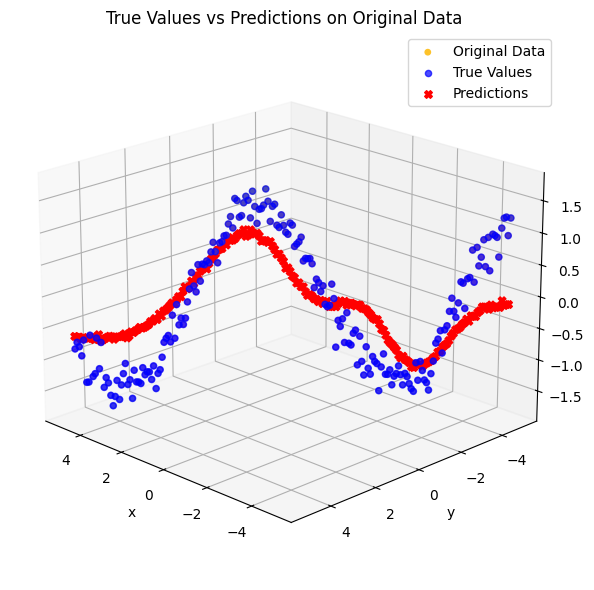

R² Train Score: 0.6505
R² Test  Score: 0.5848


In [223]:
evaluate_and_plot(regressor, 
                      X_train_scaled, y_train_scaled, 
                      X_test_scaled, y_test_scaled,
                      df_data,
                      xscaler,   # Scaler used for features
                      yscaler)   # Scaler used for target

***
# Thank you 🥳🎉 